# 1. Split

from sklearn.model_selection import 

In [54]:
import warnings
from sklearn.exceptions import FitFailedWarning

# Suppress FutureWarnings and FitFailedWarnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=FitFailedWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [55]:
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [56]:
df = pd.read_csv('data/clean_data_v1.csv')
df = df.drop(columns="Unnamed: 0")
df.head()


,RowNumber,CustomerId,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,850,2,0,43,2,125510.82,1,1,1,79084.10,0


In [57]:
X = df.iloc[:,:-1]
y = df.iloc[:, -1]

X

,RowNumber,CustomerId,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,1,15634602,619,0,0,42,2,0.00,1,1,1,101348.88
1,2,15647311,608,2,0,41,1,83807.86,1,0,1,112542.58
2,3,15619304,502,0,0,42,8,159660.80,3,1,0,113931.57
3,4,15701354,699,0,0,39,1,0.00,2,0,0,93826.63
4,5,15737888,850,2,0,43,2,125510.82,1,1,1,79084.10
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,771,0,1,39,5,0.00,2,1,0,96270.64
9996,9997,15569892,516,0,1,35,10,57369.61,1,1,1,101699.77
9997,9998,15584532,709,0,0,36,7,0.00,1,0,1,42085.58
9998,9999,15682355,772,1,1,42,3,75075.31,2,1,0,92888.52


In [58]:
TRAINING_SIZE = 0.8
RANDOM_STATE = 42

In [97]:
x_train_unbalanced, x_temp, y_train_unbalanced, y_temp = train_test_split(X, y, train_size=TRAINING_SIZE, random_state=RANDOM_STATE)
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=RANDOM_STATE)

print(len(x_train_unbalanced))
print(len(x_val))
print(len(x_test))

8000
1000
1000


# Balancing Training Dataset 

<Axes: >

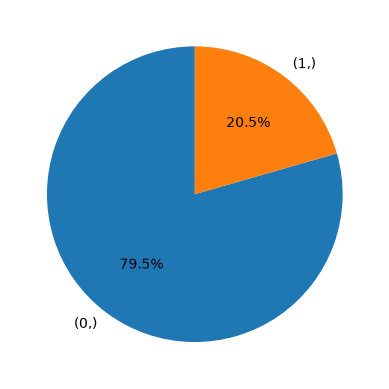

In [98]:
pd.DataFrame(y_train_unbalanced).value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90)

In [100]:
train_df = pd.DataFrame(x_train_unbalanced)
train_df['target'] = y_train_unbalanced

df_exited = train_df[train_df['target']==1]
df_not_exited = train_df[train_df['target']==0]

print("Before Balancing")
display(train_df['target'].describe())

df_not_exited = df_not_exited.sample(n=len(df_exited), random_state=RANDOM_STATE)
train_df = pd.concat([df_exited, df_not_exited])

print("="*50)
print("After Balancing")
display(train_df['target'].describe())

x_train = train_df.iloc[:,:-1]
y_train = train_df.iloc[:,-1]

Before Balancing


count    8000.000000
mean        0.205500
std         0.404092
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: target, dtype: float64

After Balancing


count    3288.000000
mean        0.500000
std         0.500076
min         0.000000
25%         0.000000
50%         0.500000
75%         1.000000
max         1.000000
Name: target, dtype: float64

# 2. Training 

In [101]:
# Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# Pipeline
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import ConfusionMatrixDisplay, f1_score, recall_score, precision_score, RocCurveDisplay

In [102]:
def display_metric(y_true, y_pred):
    f1 = f1_score(y_true=y_true, y_pred=y_pred)
    recall = recall_score(y_true=y_true, y_pred=y_pred)
    precision = precision_score(y_true=y_true, y_pred=y_pred)

    print("f1_score:", f"%{round(f1*100,4)}")
    print("recall_score:", f"%{round(recall*100,4)}")
    print("precision_score:", f"%{round(precision*100,4)}")

    ConfusionMatrixDisplay.from_predictions(y_true=y_true, y_pred=y_pred)
    print("-"*50)

    

### 2.1 Logisitic Regression

In [103]:
def get_logisitic_regression():
    first_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ('classifier', LogisticRegression(random_state=RANDOM_STATE))
    ])

    params_grid = {
        "classifier__C":[0.01, 0.1, 1],
        "classifier__penalty":["l1", "l2"],
        "classifier__solver":["liblinear", "newton-cg", "sag"]
    }

    gridSearch = GridSearchCV(estimator=first_pipeline, param_grid=params_grid, cv=5)
    gridSearch.fit(x_train, y_train)

    return gridSearch

f1_score: %43.3269
recall_score: %62.9213
precision_score: %33.0383
--------------------------------------------------


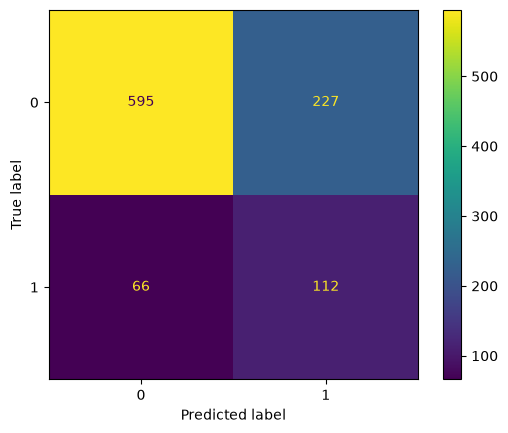

In [104]:
logistic_model = get_logisitic_regression()
y_val_pred = logistic_model.predict(x_val)
display_metric(y_val, y_val_pred)


### 2.2 Random Forest

In [105]:
def get_random_forest():
    first_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ('classifier', RandomForestClassifier(random_state=RANDOM_STATE))
    ])

    params_grid = {
        "classifier__n_estimators":[100, 200],
        "classifier__max_depth":[5,8,10,20]
    }

    gridSearch = GridSearchCV(estimator=first_pipeline, param_grid=params_grid, cv=5, scoring='average_precision')
    gridSearch.fit(x_train, y_train)

    return gridSearch

In [106]:
rf = get_random_forest()
rf_pred_y_val = rf.predict(x_val)
rf_pred_y_val_proba = rf.predict_proba(x_val)

f1_score: %40.8416
recall_score: %92.6966
precision_score: %26.1905
--------------------------------------------------


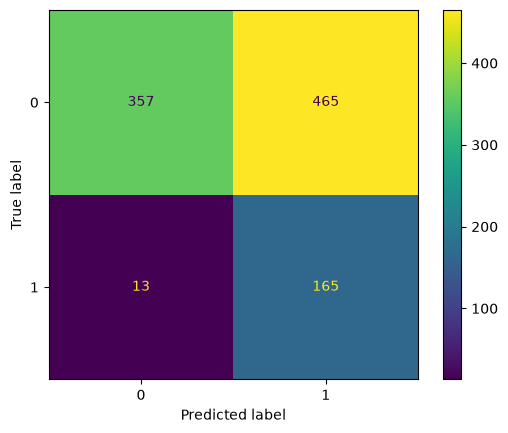

In [107]:
rf_pred_y_val_proba.shape

# for a in rf_pred_y_val_proba:
y_pred_custom = (rf_pred_y_val_proba[:, 1] >= 0.3).astype(int)
display_metric(y_val, y_pred_custom)

f1_score: %45.2107
recall_score: %33.1461
precision_score: %71.0843
--------------------------------------------------


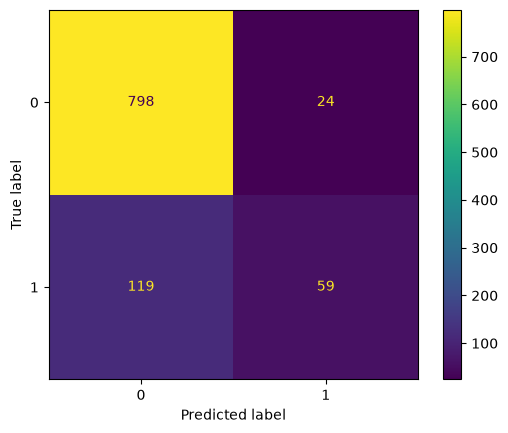

In [67]:
display_metric(y_val, rf_pred_y_val)

f1_score: %55.3314
recall_score: %56.8047
precision_score: %53.9326
--------------------------------------------------


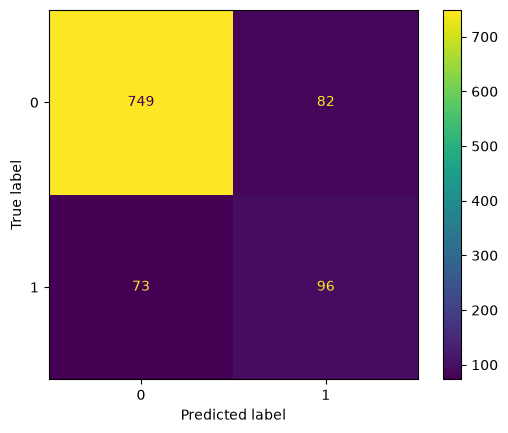

In [68]:
from sklearn.model_selection import TunedThresholdClassifierCV

# Automatically tune the threshold to maximize F1-score during fitting
tuned_model = TunedThresholdClassifierCV(
    estimator=rf.best_estimator_,
    scoring="f1",
    cv=5
)

tuned_model.fit(x_train, y_train)

# Calling predict() now uses the automatically tuned threshold instead of 0.5
y_pred_tuned = tuned_model.predict(x_val)
display_metric(y_pred_tuned, y_val)

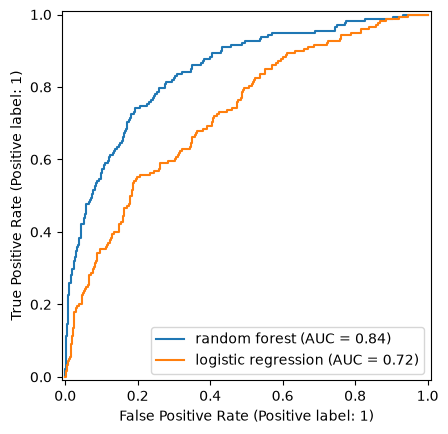

In [69]:


fig, ax = plt.subplots()

RocCurveDisplay.from_estimator(rf, x_val, y_val, ax=ax, name="random forest")
RocCurveDisplay.from_estimator(logistic_model, x_val, y_val, ax=ax, name="logistic regression")

plt.show()

# TESTING BALANACING

In [70]:
# df_exited = df[df['Exited']==1]
# df_not_exited = df[df['Exited']==0]
# df_not_exited_2 = df_not_exited.sample(n=len(df_exited))


# df_balanced = pd.concat([df_exited, df_not_exited_2])
# X2 = df_balanced.iloc[:, :-1]
# y2 = df_balanced.iloc[:, -1]
# x_train, x_test, y_train, y_test = train_test_split(X2, y2, random_state=RANDOM_STATE, test_size=0.3)

# len(df_exited), len(df_not_exited_2)

In [71]:
# model = get_random_forest(x_train, y_train)
# t = model.predict(x_test)

# display_metric(y_test, t)